# Week 6 — Prep: Transformers from scratch
### Contents

1. **Embeddings** — token embeddings, positional embeddings, geometry
2. **Scaled dot-product attention** — full derivation, the $\sqrt{d_k}$
   scaling, numerical saturation demo
3. **Multi-head attention** — why multiple heads, the rank argument
4. **The transformer block** — LayerNorm, residual connections, FFN,
   Pre-LN vs Post-LN
5. **Positional encoding** — sinusoidal (Vaswani), learned, brief RoPE
   preview
6. **Causal masking** — autoregressive generation, the mask matrix
7. **Full forward pass** — assemble everything, trace through a toy input


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math

torch.manual_seed(42)
np.random.seed(42)

%matplotlib inline

## 1. Embeddings

A transformer processes discrete tokens (words, subwords, characters).
The first step is mapping each token to a continuous vector.

### Token embeddings

The token embedding is a matrix $E \in \mathbb{R}^{V \times d}$ where $V$
is the vocabulary size and $d$ is the embedding dimension. Token $i$ maps
to row $E_i$ — a $d$-dimensional vector.

This is equivalent to multiplying a one-hot vector $e_i$ by $E$:
$\text{embed}(i) = e_i^\top E = E_i$.

### What the embedding matrix learns

Semantically similar tokens should end up with similar embedding vectors
(high cosine similarity). The SVD of $E$ reveals the effective
dimensionality of the token space — often much lower than $d$, meaning
the vocabulary occupies a low-dimensional submanifold of the embedding
space (same story as Week 3's hidden features).

### Positional embeddings

Attention is permutation-equivariant — without position information, the
model can't distinguish "the cat sat on the mat" from "mat the on sat cat
the." Positional embeddings add position-dependent vectors to the token
embeddings: $x_i = E_{\text{tok}}[w_i] + E_{\text{pos}}[i]$.

In [ ]:
# --- Token embedding: a simple example --------------------------------------
V = 50       # vocabulary size
d = 32       # embedding dimension
seq_len = 8  # sequence length

# Random "vocabulary" — in practice this is learned
torch.manual_seed(42)
tok_embed = nn.Embedding(V, d)
pos_embed = nn.Embedding(seq_len, d)

# A toy input sequence (token indices)
tokens = torch.tensor([4, 12, 7, 23, 1, 35, 18, 9])

# Embed
tok_vectors = tok_embed(tokens)                        # (8, 32)
pos_vectors = pos_embed(torch.arange(seq_len))         # (8, 32)
x = tok_vectors + pos_vectors                          # (8, 32)

print(f"Token embeddings: {tok_vectors.shape}")
print(f"Positional embeddings: {pos_vectors.shape}")
print(f"Combined: {x.shape}")

# SVD of the embedding matrix
U_e, S_e, Vt_e = torch.linalg.svd(tok_embed.weight.detach(), full_matrices=False)
var_exp = torch.cumsum(S_e**2, 0) / (S_e**2).sum()
eff_rank = int(torch.searchsorted(var_exp, 0.95).item()) + 1
print(f"\nToken embedding matrix ({V}×{d}): eff. rank = {eff_rank}")

Token embeddings: torch.Size([8, 32])
Positional embeddings: torch.Size([8, 32])
Combined: torch.Size([8, 32])

Token embedding matrix (50×32): eff. rank = 23


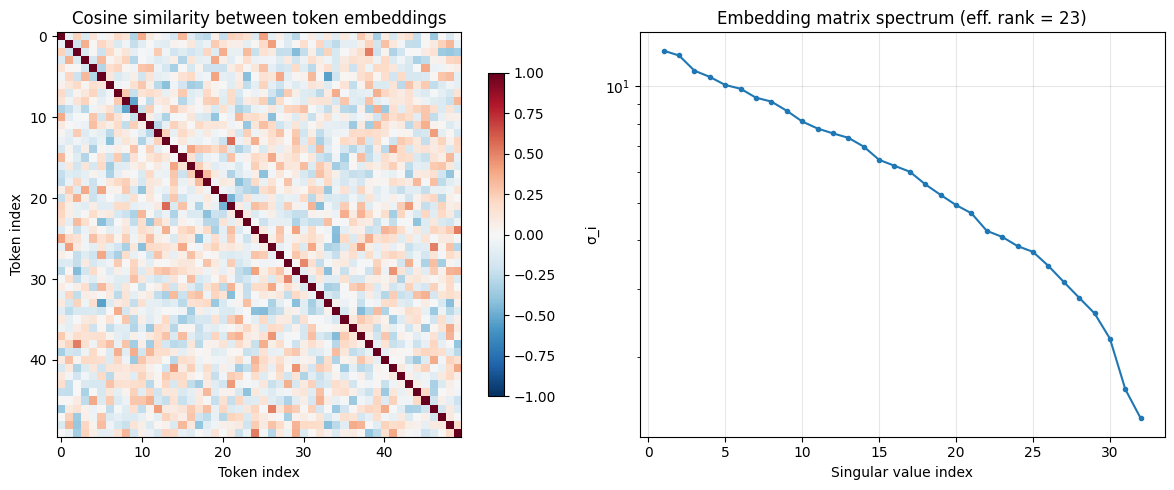

In [ ]:
# --- Cosine similarity structure in the embedding space ---------------------
with torch.no_grad():
    E = tok_embed.weight                           # (V, d)
    E_norm = E / E.norm(dim=1, keepdim=True)
    cos_sim = E_norm @ E_norm.T                    # (V, V)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
im = ax.imshow(cos_sim.numpy(), cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_title('Cosine similarity between token embeddings')
ax.set_xlabel('Token index'); ax.set_ylabel('Token index')
plt.colorbar(im, ax=ax, shrink=0.8)

ax = axes[1]
ax.semilogy(range(1, len(S_e)+1), S_e.numpy(), 'o-', markersize=3)
ax.set_xlabel('Singular value index'); ax.set_ylabel('σ_i')
ax.set_title(f'Embedding matrix spectrum (eff. rank = {eff_rank})')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Questions — Embeddings

**Q: What's the difference between token embeddings and one-hot encoding?**
> One-hot is $V$-dimensional and sparse. The embedding is $d$-dimensional
> ($d \ll V$) and dense. The embedding learns to place semantically related
> tokens nearby. One-hot treats all tokens as equidistant.

**Q: Why add positional embeddings instead of concatenating?**
> Addition keeps the dimension at $d$. Concatenation would double it to
> $2d$ and prevent the model from learning interactions between token
> identity and position in the same space. In practice, addition works well
> and is simpler.

**Q: Can you use the embedding matrix for the output layer?**
> Yes — this is called **weight tying**. The output projection
> $W_{\text{out}} \in \mathbb{R}^{d \times V}$ is set to $E^\top$.
> This halves the embedding parameter count and provides a regularization
> effect (the output space and input space share geometry). GPT-2 does
> this.

## 2. Scaled dot-product attention

### The setup

Given an input $X \in \mathbb{R}^{n \times d}$ (sequence of $n$ vectors,
each $d$-dimensional), attention computes three projections:

$$
Q = X W_Q, \quad K = X W_K, \quad V = X W_V
$$

where $W_Q, W_K \in \mathbb{R}^{d \times d_k}$ and
$W_V \in \mathbb{R}^{d \times d_v}$.

### The attention computation

$$
\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{Q K^\top}{\sqrt{d_k}}\right) V
$$

Step by step:

1. **Scores**: $S = Q K^\top \in \mathbb{R}^{n \times n}$. Entry $S_{ij}$
   measures how much position $i$ should attend to position $j$.
2. **Scale**: divide by $\sqrt{d_k}$.
3. **Normalize**: apply softmax row-wise to get attention weights
   $A \in \mathbb{R}^{n \times n}$ where each row sums to 1.
4. **Aggregate**: output $= A V \in \mathbb{R}^{n \times d_v}$. Each
   position's output is a weighted average of the value vectors.

### Why scale by $\sqrt{d_k}$?

If the entries of $Q$ and $K$ are i.i.d. with mean 0 and variance 1, then
$q_i \cdot k_j = \sum_{\ell=1}^{d_k} q_{i\ell} k_{j\ell}$ has mean 0 and
variance $d_k$ (sum of $d_k$ unit-variance terms). For large $d_k$, the
scores grow large in magnitude, pushing softmax into saturation — all
mass on one token, gradients vanish.

Dividing by $\sqrt{d_k}$ normalizes the variance back to 1, keeping
softmax in its useful (non-saturated) regime.

In [ ]:
# --- Attention from scratch --------------------------------------------------
def scaled_dot_product_attention(Q, K, V, mask=None):
    '''Compute scaled dot-product attention.

    Q: (batch, n, d_k)  or (n, d_k)
    K: (batch, n, d_k)
    V: (batch, n, d_v)
    mask: (n, n) boolean, True = allowed, False = masked

    Returns: output (batch, n, d_v), attention weights (batch, n, n)
    '''
    d_k = Q.shape[-1]
    scores = Q @ K.transpose(-2, -1) / math.sqrt(d_k)   # (n, n)

    if mask is not None:
        scores = scores.masked_fill(~mask, float('-inf'))

    attn = F.softmax(scores, dim=-1)   # (n, n), each row sums to 1
    output = attn @ V                  # (n, d_v)
    return output, attn


# --- Demonstrate on the toy sequence ----------------------------------------
d_k = d_v = 16

torch.manual_seed(0)
W_Q = nn.Linear(d, d_k, bias=False)
W_K = nn.Linear(d, d_k, bias=False)
W_V = nn.Linear(d, d_v, bias=False)

Q = W_Q(x)    # (8, 16)
K = W_K(x)
V = W_V(x)

output, attn_weights = scaled_dot_product_attention(Q, K, V)

print(f"Q shape: {Q.shape}")
print(f"Attention weights shape: {attn_weights.shape}")
print(f"Output shape: {output.shape}")
print(f"\nAttention matrix (row = query position, col = key position):")
print(attn_weights.detach().numpy().round(3))

Q shape: torch.Size([8, 16])
Attention weights shape: torch.Size([8, 8])
Output shape: torch.Size([8, 16])

Attention matrix (row = query position, col = key position):
[[0.15  0.117 0.218 0.045 0.019 0.038 0.321 0.093]
 [0.093 0.112 0.271 0.123 0.02  0.075 0.163 0.143]
 [0.125 0.162 0.268 0.047 0.044 0.179 0.117 0.057]
 [0.208 0.146 0.046 0.1   0.14  0.108 0.117 0.134]
 [0.117 0.149 0.182 0.062 0.11  0.107 0.109 0.164]
 [0.098 0.125 0.218 0.17  0.076 0.058 0.137 0.118]
 [0.231 0.056 0.034 0.185 0.34  0.097 0.038 0.018]
 [0.048 0.059 0.143 0.116 0.14  0.114 0.122 0.258]]


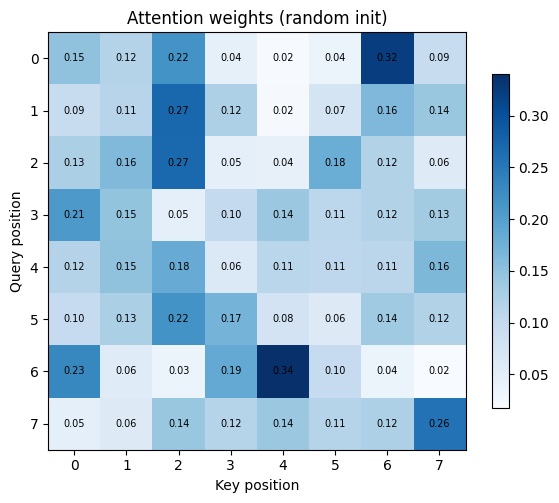

In [ ]:
# --- Visualize the attention matrix ------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(attn_weights.detach().numpy(), cmap='Blues')
ax.set_xlabel('Key position'); ax.set_ylabel('Query position')
ax.set_title('Attention weights (random init)')
for i in range(seq_len):
    for j in range(seq_len):
        ax.text(j, i, f'{attn_weights[i,j].item():.2f}',
                ha='center', va='center', fontsize=7)
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

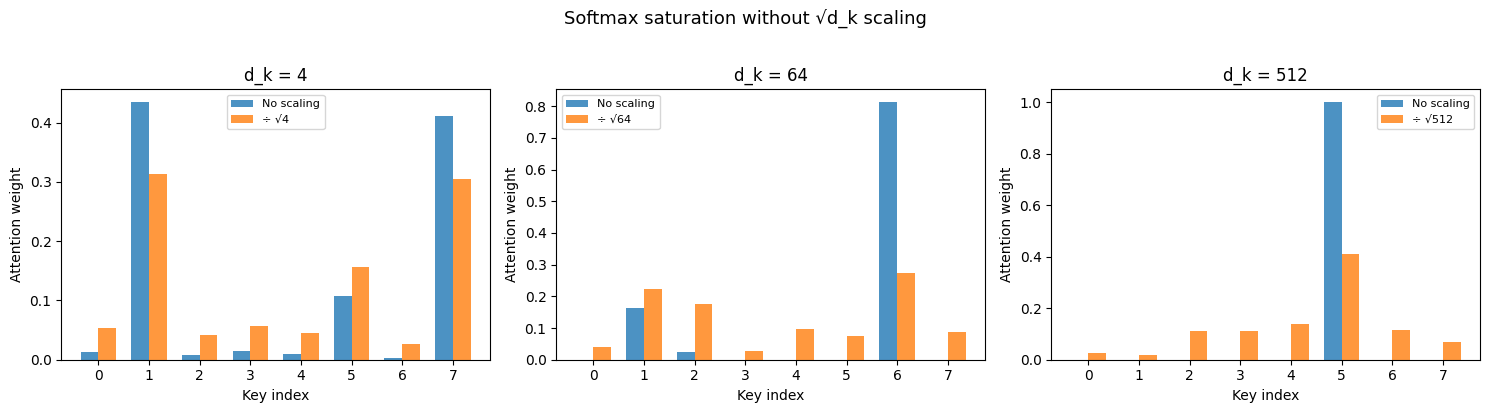

In [ ]:
# --- The sqrt(d_k) scaling: saturation demo ---------------------------------
# Show what happens without the scaling for different d_k values

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, dk in zip(axes, [4, 64, 512]):
    torch.manual_seed(0)
    q = torch.randn(1, dk)     # single query
    K_rand = torch.randn(8, dk)  # 8 keys

    # Without scaling
    scores_raw = (q @ K_rand.T).squeeze()   # (8,)
    attn_raw = F.softmax(scores_raw, dim=0)

    # With scaling
    scores_scaled = scores_raw / math.sqrt(dk)
    attn_scaled = F.softmax(scores_scaled, dim=0)

    x_pos = np.arange(8)
    width = 0.35
    ax.bar(x_pos - width/2, attn_raw.numpy(), width, label='No scaling', alpha=0.8)
    ax.bar(x_pos + width/2, attn_scaled.numpy(), width, label=f'÷ √{dk}', alpha=0.8)
    ax.set_title(f'd_k = {dk}')
    ax.set_xlabel('Key index'); ax.set_ylabel('Attention weight')
    ax.legend(fontsize=8)

plt.suptitle('Softmax saturation without √d_k scaling', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Questions — Attention

**Q: What's the computational complexity of self-attention?**
> $O(n^2 d)$ where $n$ is the sequence length and $d$ is the dimension.
> The $QK^\top$ multiplication is $O(n^2 d_k)$ and produces an $n \times n$
> matrix. For long sequences, this quadratic scaling is the bottleneck.

**Q: What's the memory complexity?**
> $O(n^2)$ for storing the attention matrix. This is often the binding
> constraint before the compute cost — Flash Attention addresses this.

**Q: Is the attention matrix always low-rank?**
> Empirically, yes — trained attention matrices often have effective rank
> much lower than $n$. This motivates low-rank attention approximations
> (Linformer, Performer). We'll verify this on GPT-2 in the week 6
> session.

**Q: What does each row of the attention matrix represent?**
> Row $i$ is the distribution over key positions that query position $i$
> attends to. It sums to 1 (softmax). The output at position $i$ is the
> weighted average of value vectors according to this distribution.

## 3. Multi-head attention

### Why multiple heads?

A single attention head computes one attention pattern — one way of
relating positions. But language has multiple types of relationships
simultaneously (syntactic, semantic, positional). Multiple heads let the
model attend to different aspects in parallel.

### The rank argument

A single head updates each position by a weighted average of value vectors:
$\text{output}_i = \sum_j A_{ij} v_j$. This is a single linear combination
— it produces a **rank-1 update** to the residual stream per head (each
position gets a vector from the span of $\{v_j\}$, weighted by one set of
coefficients).

With $h$ heads, the concatenated output is rank-$h$ — much richer.

### Implementation

Split $d$ into $h$ heads of dimension $d_k = d/h$ each. Run attention
independently per head, concatenate, and project:

$$
\text{MultiHead}(X) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h) W_O
$$

where $W_O \in \mathbb{R}^{d \times d}$ is the output projection.

In [ ]:
class MultiHeadAttention(nn.Module):
    '''Multi-head self-attention.

    d_model: total model dimension
    n_heads: number of attention heads (must divide d_model)
    '''
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x, mask=None):
        '''x: (batch, seq_len, d_model) or (seq_len, d_model)
        Returns: output, attention_weights (per head)
        '''
        if x.dim() == 2:
            x = x.unsqueeze(0)    # add batch dim
        B, N, D = x.shape

        # Project to Q, K, V
        Q = self.W_Q(x)   # (B, N, d_model)
        K = self.W_K(x)
        V = self.W_V(x)

        # Reshape to (B, n_heads, N, d_k)
        Q = Q.reshape(B, N, self.n_heads, self.d_k).transpose(1, 2)
        K = K.reshape(B, N, self.n_heads, self.d_k).transpose(1, 2)
        V = V.reshape(B, N, self.n_heads, self.d_k).transpose(1, 2)

        # Scaled dot-product attention per head
        scores = Q @ K.transpose(-2, -1) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(~mask.unsqueeze(0).unsqueeze(0), float('-inf'))
        attn = F.softmax(scores, dim=-1)    # (B, n_heads, N, N)
        head_outputs = attn @ V              # (B, n_heads, N, d_k)

        # Concatenate heads and project
        concat = head_outputs.transpose(1, 2).reshape(B, N, D)
        output = self.W_O(concat)

        return output.squeeze(0), attn.squeeze(0)


# --- Demo -------------------------------------------------------------------
torch.manual_seed(42)
mha = MultiHeadAttention(d_model=d, n_heads=4)
out, attn = mha(x)    # x is (8, 32) from earlier

print(f"Input: {x.shape}")
print(f"Output: {out.shape}")
print(f"Attention per head: {attn.shape}  (4 heads, 8×8 each)")

Input: torch.Size([8, 32])
Output: torch.Size([8, 32])
Attention per head: torch.Size([4, 8, 8])  (4 heads, 8×8 each)


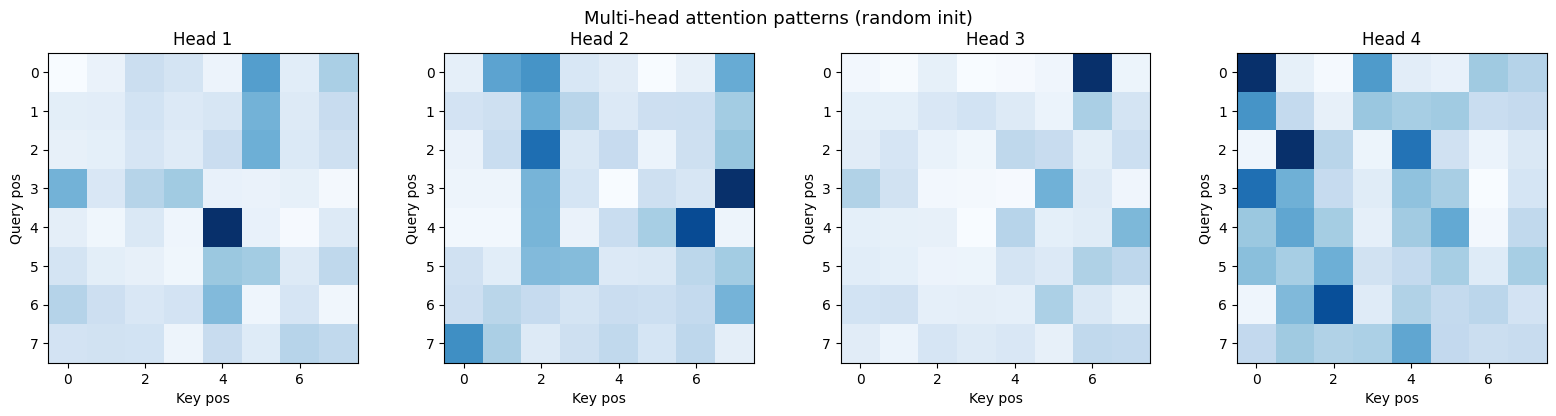

In [ ]:
# --- Visualize attention patterns per head -----------------------------------
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for h in range(4):
    ax = axes[h]
    im = ax.imshow(attn[h].detach().numpy(), cmap='Blues')
    ax.set_title(f'Head {h+1}')
    ax.set_xlabel('Key pos'); ax.set_ylabel('Query pos')
plt.suptitle('Multi-head attention patterns (random init)', fontsize=13)
plt.tight_layout()
plt.show()

### Questions — Multi-head attention

**Q: Why not just use one head with larger $d_k$?**
> A single head with $d_k = d$ computes one attention pattern. Multiple
> heads with $d_k = d/h$ each can learn $h$ different patterns
> simultaneously — different heads can specialize in syntactic structure,
> semantic similarity, positional proximity, etc. The concatenation gives
> a richer (higher-rank) update to the residual stream.

**Q: What's the total parameter count of multi-head attention?**
> Four projection matrices: $W_Q, W_K, W_V, W_O$, each $d \times d$.
> Total: $4d^2$ parameters (ignoring bias). This is independent of the
> number of heads — splitting into heads doesn't change the parameter
> count, just how the computation is organized.

**Q: Can different heads learn redundant patterns?**
> Yes — and they often do. This is why head pruning works (Week 6 student
> session). Many heads can be removed with minimal performance impact.

## 4. The transformer block

A transformer block combines multi-head attention with a feed-forward
network, connected by residual connections and layer normalization.

### Pre-LN formulation (GPT-2 style)

$$
\begin{aligned}
h &= x + \text{MHA}(\text{LN}(x)) \\
\text{out} &= h + \text{FFN}(\text{LN}(h))
\end{aligned}
$$

### Components

**Layer Normalization**: normalizes each token's vector to zero mean and
unit variance, then applies a learned affine transform:
$\text{LN}(x) = \gamma \odot \frac{x - \mu}{\sigma + \epsilon} + \beta$.
Unlike BatchNorm, this operates per-token (not per-batch), so it works
with variable-length sequences.

**Residual connections**: $\text{out} = x + f(x)$. Without the residual,
the network computes $f(x)$ — an arbitrary nonlinear function. With the
residual, it computes $x + f(x)$ — the identity plus a learned
perturbation. This keeps the gradient flowing (Week 5: skip connections
smooth the loss landscape).

**Feed-forward network**: two linear layers with an activation in between:
$\text{FFN}(x) = W_2 \,\text{GELU}(W_1 x + b_1) + b_2$, where
$W_1 \in \mathbb{R}^{d \times 4d}$ and $W_2 \in \mathbb{R}^{4d \times d}$.
The expansion to $4d$ gives the network capacity to represent complex
per-token transformations. **Most of the transformer's parameters live in
the FFN, not in attention.**

### Where the parameters are (GPT-2 small, $d=768$, 12 layers)

| Component | Params per layer | Total (12 layers) |
|-----------|-----------------|-------------------|
| MHA ($4d^2$) | 2.4M | 28.3M |
| FFN ($8d^2$) | 4.7M | 56.6M |
| LN (2 per layer, $2 \times 2d$) | 3k | 37k |
| **Total per layer** | **~7.1M** | **~85M** |
| Embeddings ($V \times d$) | — | ~38M |
| **Grand total** | — | **~124M** |

The FFN has 2× the parameters of MHA. It's often described as the
"memory" of the transformer — where factual knowledge is stored.

In [ ]:
class TransformerBlock(nn.Module):
    '''Pre-LN transformer block (GPT-2 style).'''
    def __init__(self, d_model, n_heads, d_ff=None, dropout=0.0):
        super().__init__()
        if d_ff is None:
            d_ff = 4 * d_model

        self.ln1 = nn.LayerNorm(d_model)
        self.mha = MultiHeadAttention(d_model, n_heads)
        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model),
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # Pre-LN: normalize before each sub-layer
        attn_out, attn_weights = self.mha(self.ln1(x), mask=mask)
        x = x + self.dropout(attn_out)        # residual
        x = x + self.dropout(self.ffn(self.ln2(x)))  # residual
        return x, attn_weights


# --- Demo -------------------------------------------------------------------
torch.manual_seed(42)
block = TransformerBlock(d_model=d, n_heads=4)
out_block, attn_block = block(x)

print(f"Input: {x.shape}")
print(f"Output: {out_block.shape}")
print(f"Residual connection: out ≈ x + small perturbation")
print(f"  ‖x‖ = {x.norm():.4f}")
print(f"  ‖out - x‖ = {(out_block - x).norm():.4f}")
print(f"  ‖out‖ = {out_block.norm():.4f}")

Input: torch.Size([8, 32])
Output: torch.Size([8, 32])
Residual connection: out ≈ x + small perturbation
  ‖x‖ = 22.7729
  ‖out - x‖ = 3.4802
  ‖out‖ = 22.9882


### Questions — Transformer block

**Q: Why LayerNorm and not BatchNorm?**
> BatchNorm computes statistics across the batch dimension. For sequences
> of variable length, batch statistics are noisy and padding complicates
> things. LayerNorm computes statistics per-token, independent of other
> sequences in the batch, making it robust to variable-length inputs.

**Q: Pre-LN vs Post-LN — what's the difference?**
> Post-LN (original Vaswani): $\text{LN}(x + f(x))$. Pre-LN (GPT-2):
> $x + f(\text{LN}(x))$. Pre-LN is easier to train — the residual path
> is clean (no normalization on the skip connection), so gradients flow
> more freely. Most modern transformers use Pre-LN.

**Q: Why does the FFN expand to $4d$ and back?**
> The expansion creates a wider representation where the GELU activation
> can select/combine features. The bottleneck back to $d$ forces
> compression. This expand-activate-compress pattern is similar to the
> MLP's hidden layer — it's a nonlinear transformation with a learned
> basis.

**Q: Where is factual knowledge stored in a transformer?**
> Primarily in the FFN weights. The attention mechanism routes information
> between positions; the FFN processes it. This is supported by
> experiments showing that editing FFN weights can change the model's
> factual outputs (ROME, MEMIT).

## 5. Positional encoding

### The permutation equivariance problem

Without positional information, self-attention is
**permutation-equivariant**: if you permute the input tokens, the output
permutes in the same way. The attention scores $Q K^\top$ depend only on
the *content* of the tokens, not their position.

Proof sketch: let $P$ be a permutation matrix. Then:
$\text{Attention}(PX) = P \,\text{softmax}((PX W_Q)(PX W_K)^\top / \sqrt{d_k}) \,(PX W_V)$
$= P \,\text{softmax}(P S P^\top) \,P V$. Since softmax is applied
row-wise and $P$ just reorders rows/columns:
$= P \,A \,V = P \,\text{Attention}(X)$.

So the model can't distinguish "dog bites man" from "man bites dog."
Positional encoding breaks this symmetry.

### Sinusoidal encoding (Vaswani et al., 2017)

$$
\text{PE}(pos, 2i) = \sin(pos / 10000^{2i/d}), \quad
\text{PE}(pos, 2i+1) = \cos(pos / 10000^{2i/d})
$$

**Key property**: the encoding of position $pos + k$ is a linear function
of the encoding at position $pos$ (rotation in 2D subspaces). This means
relative position information is accessible via linear operations — the
model can learn to compute "how far apart are these two tokens?" from
their positional encodings.

### Learned positional embeddings

Simply a learnable matrix $P \in \mathbb{R}^{L_{\max} \times d}$ where
$L_{\max}$ is the maximum sequence length. Each position gets its own
learned vector. GPT-2 uses this.

**Tradeoff**: learned embeddings can't extrapolate beyond $L_{\max}$.
Sinusoidal can in principle (the formula works for any $pos$), though in
practice the model hasn't seen those positions during training.

### RoPE

Rotary Position Embedding encodes position by *rotating* the query and key
vectors rather than adding to the embeddings. The rotation angle depends
on position, so the dot product $q_i \cdot k_j$ naturally encodes relative
position $i - j$. This has become the standard for modern LLMs (LLaMA,
Mistral, etc.).

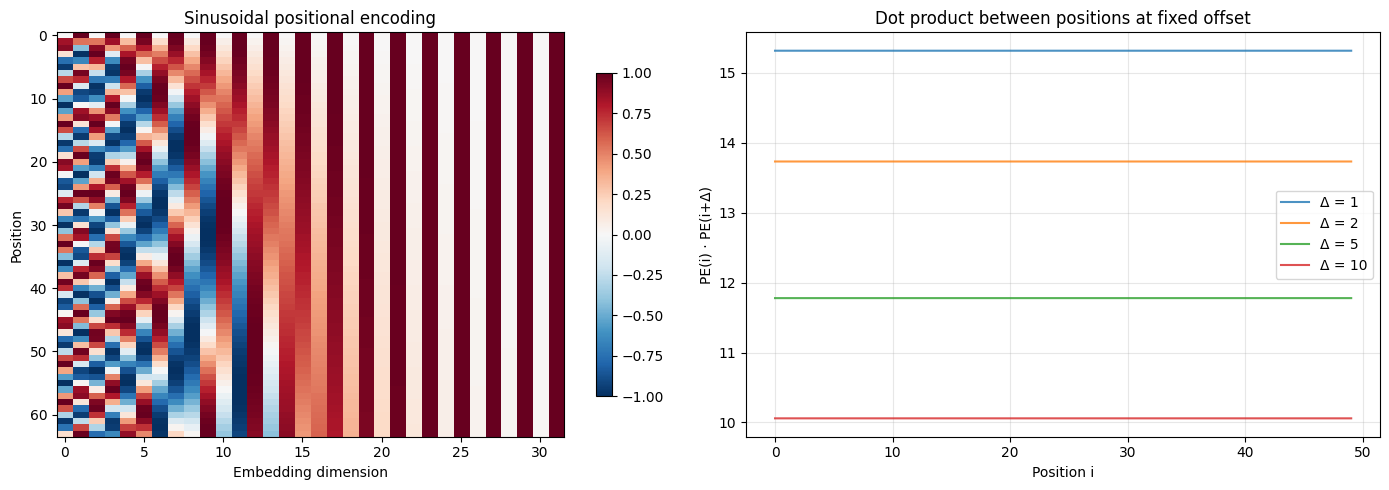

In [ ]:
# --- Sinusoidal positional encoding ------------------------------------------
def sinusoidal_pe(max_len, d_model):
    '''Generate sinusoidal positional encoding matrix (max_len, d_model).'''
    pe = torch.zeros(max_len, d_model)
    position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2).float() *
                         -(math.log(10000.0) / d_model))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe

pe = sinusoidal_pe(64, d)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
im = ax.imshow(pe.numpy(), cmap='RdBu_r', aspect='auto')
ax.set_xlabel('Embedding dimension'); ax.set_ylabel('Position')
ax.set_title('Sinusoidal positional encoding')
plt.colorbar(im, ax=ax, shrink=0.8)

# Show that relative positions are encoded linearly
ax = axes[1]
for delta in [1, 2, 5, 10]:
    # Dot product between position i and position i+delta
    dots = [(pe[i] * pe[i+delta]).sum().item() for i in range(50)]
    ax.plot(dots, label=f'Δ = {delta}', alpha=0.8)
ax.set_xlabel('Position i'); ax.set_ylabel('PE(i) · PE(i+Δ)')
ax.set_title('Dot product between positions at fixed offset')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Questions — Positional encoding

**Q: Why not just use the integer position as a feature?**
> The integer would dominate other features at large positions. Also,
> the model would need to learn that "position 100" and "position 101" are
> adjacent — with sinusoidal encoding, adjacency is built into the
> representation via the rotation structure.

**Q: Can a transformer generalize to longer sequences than it saw during
training?**
> With sinusoidal: the encoding formula works for any position, but the
> model hasn't been trained on attention patterns at those distances.
> With learned: strictly no — there's no embedding for unseen positions.
> With RoPE: better extrapolation because it encodes relative position,
> though performance still degrades. This is an active research area
> (ALiBi, YaRN, etc.).

## 6. Causal masking

For autoregressive language models (GPT-style), position $i$ should only
attend to positions $j \leq i$ — it can't look into the future.

The causal mask is a lower-triangular boolean matrix:

$$
M_{ij} = \begin{cases} 1 & \text{if } j \leq i \\ 0 & \text{if } j > i \end{cases}
$$

Applied to the attention scores before softmax:
$S_{ij} \leftarrow S_{ij}$ if $M_{ij} = 1$, else $-\infty$.
After softmax, the $-\infty$ entries become 0 — position $i$ can't attend
to future positions.

Causal mask (1 = attend, 0 = masked):
[[1 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0]
 [1 1 1 0 0 0 0 0]
 [1 1 1 1 0 0 0 0]
 [1 1 1 1 1 0 0 0]
 [1 1 1 1 1 1 0 0]
 [1 1 1 1 1 1 1 0]
 [1 1 1 1 1 1 1 1]]


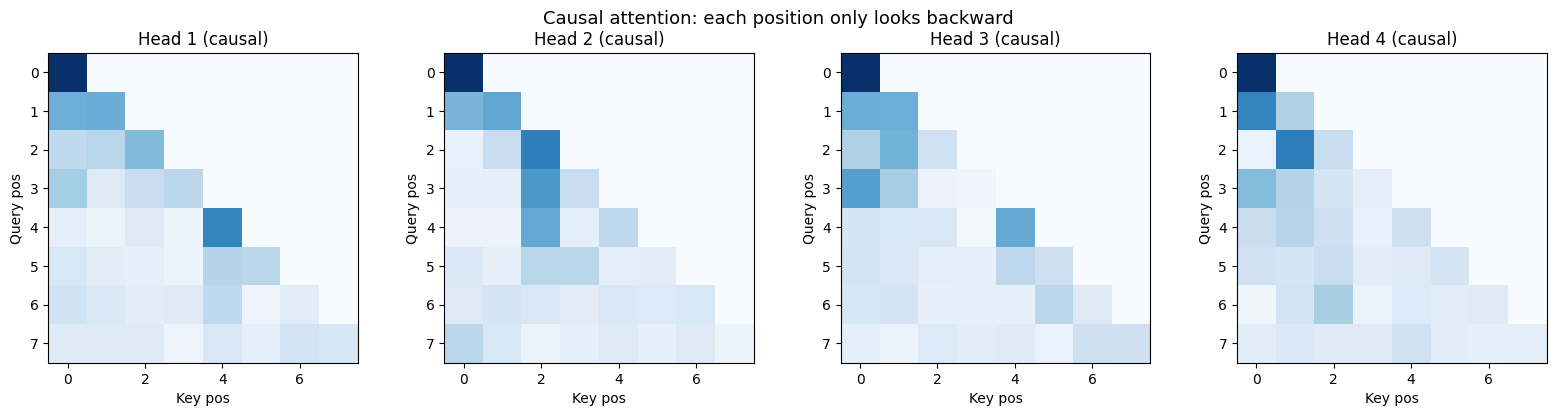

In [ ]:
# --- Causal mask demo --------------------------------------------------------
n = 8
causal_mask = torch.tril(torch.ones(n, n, dtype=torch.bool))

print("Causal mask (1 = attend, 0 = masked):")
print(causal_mask.int().numpy())

# Attention with causal mask
torch.manual_seed(42)
mha_causal = MultiHeadAttention(d_model=d, n_heads=4)
out_causal, attn_causal = mha_causal(x, mask=causal_mask)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for h in range(4):
    ax = axes[h]
    ax.imshow(attn_causal[h].detach().numpy(), cmap='Blues')
    ax.set_title(f'Head {h+1} (causal)')
    ax.set_xlabel('Key pos'); ax.set_ylabel('Query pos')
plt.suptitle('Causal attention: each position only looks backward', fontsize=13)
plt.tight_layout()
plt.show()

### Questions — Causal masking

**Q: Why use masking instead of just feeding shorter sequences?**
> Masking allows parallel computation during training. Without the mask,
> you'd need $n$ separate forward passes for a sequence of length $n$.
> With the mask, one forward pass computes all $n$ outputs simultaneously,
> each seeing only its valid context.

**Q: What's the KV-cache? (preview)**
> During autoregressive generation, each new token only needs to compute
> its own $Q$ but attend to all previous $K, V$. The KV-cache stores
> the previously computed $K$ and $V$ so they don't need recomputation.
> This turns generation from $O(n^2)$ per token to $O(n)$ per token.
> Detailed in Prep Notebook 3.

## 7. Full forward pass — assembling the transformer

Let's build a complete (small) transformer and trace a forward pass.

In [ ]:
class SmallTransformer(nn.Module):
    '''A minimal GPT-style transformer for language modeling.'''
    def __init__(self, vocab_size, d_model=64, n_heads=4,
                 n_layers=2, max_len=128):
        super().__init__()
        # Use the arguments directly; ensure they are standard Python ints
        self.vocab_size = vocab_size
        self.d_model = d_model

        self.tok_embed = nn.Embedding(self.vocab_size, self.d_model)
        self.pos_embed = nn.Embedding(max_len, self.d_model)
        self.blocks = nn.ModuleList([
            TransformerBlock(self.d_model, n_heads) for _ in range(n_layers)
        ])
        self.ln_final = nn.LayerNorm(self.d_model)
        self.head = nn.Linear(self.d_model, self.vocab_size, bias=False)

    def forward(self, token_ids, return_intermediates=False):
        if token_ids.dim() == 1:
            token_ids = token_ids.unsqueeze(0)
        B, N = token_ids.shape

        # Embeddings
        tok = self.tok_embed(token_ids)
        pos = self.pos_embed(torch.arange(N, device=token_ids.device))
        x = tok + pos

        # Causal mask
        mask = torch.tril(torch.ones(N, N, dtype=torch.bool,
                                     device=token_ids.device))

        # Transformer blocks
        intermediates = [x.detach().clone()]
        all_attn = []
        for block in self.blocks:
            x, attn = block(x, mask=mask)
            intermediates.append(x.detach().clone())
            all_attn.append(attn)

        # Final LN + output projection
        x = self.ln_final(x)
        logits = self.head(x)    # (B, N, vocab_size)

        if return_intermediates:
            return logits.squeeze(0), intermediates, all_attn
        return logits.squeeze(0)

# --- Trace a forward pass ---------------------------------------------------
torch.manual_seed(42)
# Force V and d to be standard integers to avoid any tensor-conversion errors
current_V = 50
current_d = 32

model = SmallTransformer(vocab_size=current_V, d_model=current_d, n_heads=4, n_layers=2)

logits, intermediates, all_attn = model(tokens, return_intermediates=True)

print(f"Input tokens: {tokens.shape}")
print(f"Output logits: {logits.shape}  (one distribution over {current_V} tokens per position)")
print(f"\nIntermediate residual stream shapes:")
for i, h in enumerate(intermediates):
    print(f"  After {'embed' if i == 0 else f'block {i}'}: {h.shape}, "
          f"‖h‖ = {h.norm():.2f}")

print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

Input tokens: torch.Size([8])
Output logits: torch.Size([8, 50])  (one distribution over 50 tokens per position)

Intermediate residual stream shapes:
  After embed: torch.Size([1, 8, 32]), ‖h‖ = 22.77
  After block 1: torch.Size([1, 8, 32]), ‖h‖ = 23.13
  After block 2: torch.Size([1, 8, 32]), ‖h‖ = 24.24

Total parameters: 32,512
